TV-Regularized Computed Laminography Reconstruction
===================================================

This example demonstrates solution of a sparse-view CT reconstruction
problem with isotropic total variation (TV) regularization

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| \mathbf{y} - A \mathbf{x}
  \|_2^2 + \lambda \| C \mathbf{x} \|_{2,1} \;,$$

where $A$ is the X-ray transform (the CT forward projection operator),
$\mathbf{y}$ is the sinogram, $C$ is a 2D finite difference operator, and
$\mathbf{x}$ is the reconstructed image. This example uses the CT
projector integrated into scico, while the companion
[example script](ct_astra_tv_admm.rst) uses the projector provided by
the astra package.

In [1]:
import numpy as np

import jax

import komplot as kplt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scico.numpy as snp
from scico import functional, linop, loss, metric, optimize
from scico.examples import create_laminar_phantom
from scico.linop.xray import XRayTransform3D as scicoXRayTransform3D
from scico.linop.xray import cl_angles_to_vecs, cl_fbp
from scico.linop.xray.astra import XRayTransform3D as astraXRayTransform3D
from scico.linop.xray.astra import convert_to_scico_geometry
from scico.util import device_info
kplt.config_notebook_plotting()

have_gpu = True if jax.devices()[0].platform == "gpu" else False

Create a ground truth image.

In [2]:
x_gt = create_laminar_phantom()

Configure projection operator and generate synthetic measurements.

In [3]:
vol_shape = x_gt.shape
det_shape = (int(vol_shape[1] * 0.85), int(vol_shape[2] * 1.4))
num_views = 180
alpha = 61.0 * np.pi / 180.0
theta = np.linspace(0, 2 * np.pi, num_views, endpoint=False)
vectors = cl_angles_to_vecs(theta, alpha)

if have_gpu:  # use astra projector
    X = astraXRayTransform3D(
        vol_shape,
        det_count=det_shape,
        vectors=vectors,
    )
else:  # use scico projector
    matrices = convert_to_scico_geometry(
        input_shape=vol_shape, det_count=det_shape, vectors=vectors
    )
    X = scicoXRayTransform3D(vol_shape, matrices, det_shape)


y = X @ x_gt
yn = y + 0.05 * np.random.rand(*y.shape).astype(np.float32)

Compute FBP solution for comparison and as initial solution.

In [4]:
x_fbp = snp.clip(cl_fbp(y, alpha, X), 0.0, 1.0)

Set up problem functional and APGM solver object.

In [5]:
f = loss.SquaredL2Loss(y=yn, A=X)
λ = 1e0
g = λ * functional.IsotropicTVNorm(circular=False, input_shape=vol_shape)
maxiter = 200
print("Estimating L0")
L0 = linop.operator_norm(X, maxiter=10) ** 2

solver = optimize.AcceleratedPGM(
    f=f,
    g=g,
    L0=L0,
    x0=x_fbp,
    maxiter=maxiter,
    itstat_options={"display": True, "period": 20},
)

Estimating L0


Run the solver.

In [6]:
print(f"Solving on {device_info()}\n")
x_rec = snp.clip(solver.solve(), 0.0, 1.0)
hist = solver.itstat_object.history(transpose=True)

Solving on GPU  0  NVIDIA GeForce RTX 2080 Ti



Iter  Time      Objective  L          Residual 
-----------------------------------------------
   0  3.41e+00  6.183e+07  1.706e+04  1.086e+02


  20  4.74e+01  1.189e+06  1.706e+04  9.926e-01


  40  9.13e+01  4.658e+05  1.706e+04  2.745e-01


  60  1.35e+02  3.828e+05  1.706e+04  1.467e-01


...

 120  2.67e+02  3.232e+05  1.706e+04  5.751e-02


 140  3.10e+02  3.130e+05  1.706e+04  4.621e-02


 160  3.54e+02  3.056e+05  1.706e+04  4.042e-02


 180  3.98e+02  2.997e+05  1.706e+04  3.539e-02


 199  4.39e+02  2.953e+05  1.706e+04  3.245e-02


Show the recovered image.

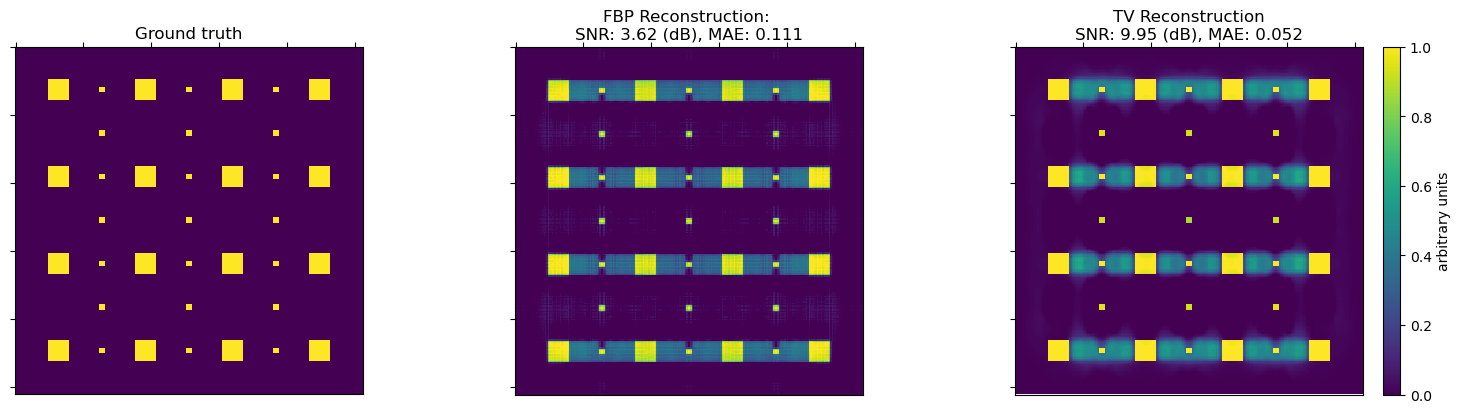

In [7]:
slice_index = 32
fig, ax = kplt.subplots(nrows=1, ncols=3, layout="constrained", figsize=(15, 5))
kplt.imview(x_gt[slice_index], title="Ground truth", show_cbar=None, cmap="viridis", ax=ax[0])
kplt.imview(
    x_fbp[slice_index],
    title="FBP Reconstruction: \nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(x_gt, x_fbp), metric.mae(x_gt, x_fbp)),
    show_cbar=None,
    cmap="viridis",
    ax=ax[1],
)
kplt.imview(
    x_rec[slice_index],
    title="TV Reconstruction\nSNR: %.2f (dB), MAE: %.3f"
    % (metric.snr(x_gt, x_rec), metric.mae(x_gt, x_rec)),
    cmap="viridis",
    ax=ax[2],
)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.2)
fig.colorbar(ax[2].get_images()[0], cax=cax, label="arbitrary units")
fig.set_constrained_layout_pads(w_pad=0.55, wspace=0)
fig.show()

Plot convergence statistics.

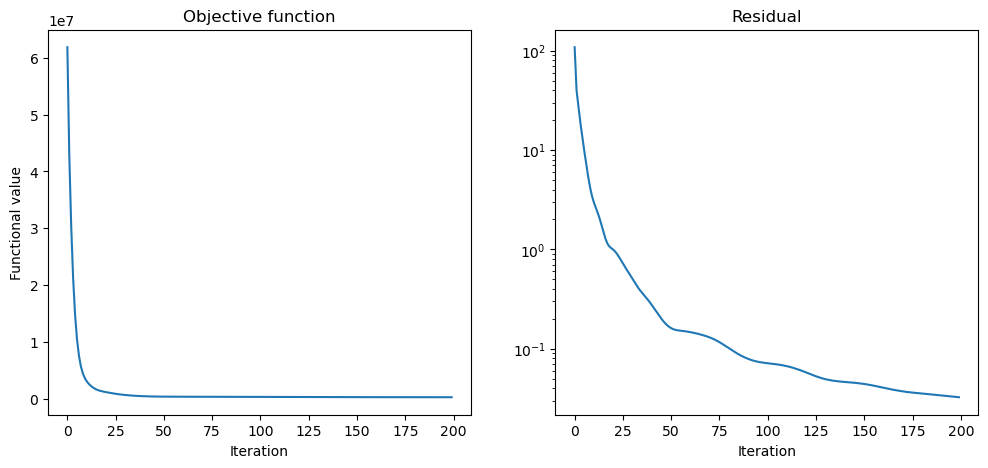

In [8]:
fig, ax = kplt.subplots(nrows=1, ncols=2, figsize=(12, 5))
kplt.plot(
    hist.Objective,
    title="Objective function",
    xlabel="Iteration",
    ylabel="Functional value",
    ax=ax[0],
)
kplt.plot(
    hist.Residual,
    ylog=True,
    title="Residual",
    xlabel="Iteration",
    ax=ax[1],
)
fig.show()